# Exploratory Data Analysis (EDA) on Retail Sales Data

## Oasis Infobyte Data Analytics Internship

**Track:** Data Analytics

**Task:** Task 1 - Exploratory Data Analysis (EDA) on Retail Sales Data

### Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to understand customer purchasing behavior, identify sales trends, analyze product performance, and generate meaningful business insights using Python.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset

df = pd.read_csv("retail_sales_dataset (1).csv")

# Display first 5 rows

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Dataset Preview

The first five records of the dataset are displayed to understand the structure of the data, available columns, and sample values before performing further analysis.

# Initial Dataset Inspection

The dataset is inspected to understand its dimensions, column names, data types, and missing values. This helps identify the overall structure and determine the preprocessing steps required before analysis.

In [2]:
# Display the shape of the dataset

print("Shape of Dataset:", df.shape)

Shape of Dataset: (1000, 9)


### Observation

The shape of the dataset shows the total number of rows (records) and columns (features) available for analysis.

In [3]:
# Display column names

df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

### Observation

The dataset contains columns related to customer information, transaction details, product category, quantity purchased, pricing, and total sales amount.

In [4]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


### Observation

The dataset information displays the data type of each column, the total number of non-null values, and memory usage. This helps identify categorical and numerical features as well as missing values.

In [5]:
# Check missing values

df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

### Observation

No missing values are present in the dataset. All columns contain complete records, indicating that the dataset is ready for further analysis without requiring missing value treatment.

# Descriptive Statistics

Descriptive statistics provide a summary of the numerical features in the dataset. These measures help understand the distribution, central tendency, and variability of the data.

In [6]:
# Generate descriptive statistics

df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


## Observation

The statistical summary provides information about:

- Count
- Mean
- Median (50%)
- Standard Deviation
- Minimum Value
- Maximum Value
- Quartiles (25%, 50%, 75%)

These statistics help understand the distribution of numerical variables and identify any unusual values or potential outliers.

In [7]:
# Calculate median

df.median(numeric_only=True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [8]:
# Calculate mode

df.mode().head(1)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-05-16,CUST001,Female,43.0,Clothing,4.0,50.0,50.0


In [9]:
# Calculate standard deviation

df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

## Observation

The calculated median, mode, and standard deviation provide additional insights into the central tendency and spread of the numerical variables. These measures help compare the distribution of different features in the dataset.

# Data Cleaning

The dataset is checked for duplicate records and appropriate data types before performing exploratory analysis.

The **Date** column is converted into datetime format to enable time-based analysis such as monthly and quarterly sales trends.

In [10]:
# Check duplicate records

df.duplicated().sum()

np.int64(0)

## Observation

The dataset is checked for duplicate records to ensure data quality before analysis.

In [11]:
# Convert Date column into datetime format

df["Date"] = pd.to_datetime(df["Date"])

In [12]:
# Verify data types

df.dtypes

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

## Observation

The **Date** column has been successfully converted into datetime format, making it suitable for time series analysis.

In [13]:
# Create Month and Quarter columns

df["Month"] = df["Date"].dt.to_period("M")
df["Quarter"] = df["Date"].dt.to_period("Q")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,2023Q4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,2023Q1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,2023Q1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05,2023Q2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05,2023Q2


## Observation

Two new columns, **Month** and **Quarter**, have been created from the Date column. These features will be used to analyze monthly and quarterly sales trends.

## Monthly Sales Trend

Monthly sales analysis helps identify seasonal patterns and sales performance over different months.

A line chart is used to visualize the total sales generated in each month.

In [14]:
# Calculate monthly sales

monthly_sales = df.groupby("Month")["Total Amount"].sum()

monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

## Monthly Sales Trend Visualization

The following line chart illustrates the total sales generated in each month. This visualization helps identify seasonal trends, peak sales periods, and months with lower revenue.

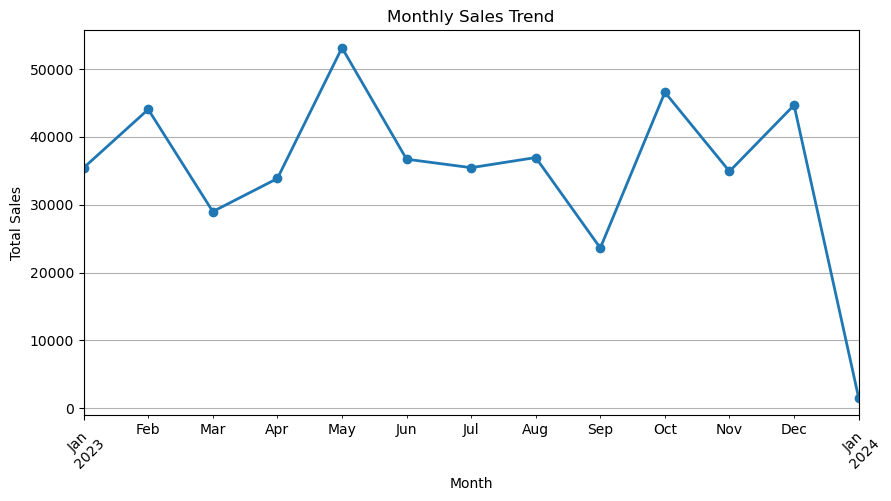

In [15]:
# Plot Monthly Sales Trend

plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind="line",
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation

The monthly sales trend illustrates how total sales vary across different months. Peaks in the graph indicate months with higher sales, while dips represent relatively lower sales periods. This visualization helps identify seasonal demand patterns and supports better business planning.

# Quarterly Sales Trend

Quarterly sales analysis provides a broader view of business performance by grouping sales into quarters. This helps identify long-term sales patterns and compare performance across different quarters.

In [16]:
# Calculate quarterly sales

quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

## Observation

The quarterly sales summary displays the total revenue generated in each quarter. This provides a high-level overview of business performance throughout the year.

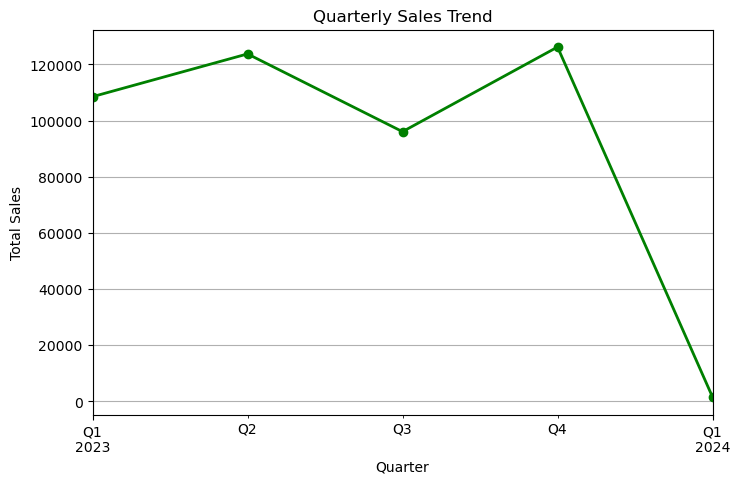

In [17]:
# Plot Quarterly Sales Trend

plt.figure(figsize=(8,5))

quarterly_sales.plot(
    kind="line",
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

## Observation

The quarterly sales trend highlights changes in revenue across different quarters. Comparing quarterly performance helps identify periods of strong sales and supports long-term business planning.

# Customer Demographics Analysis

Customer demographic analysis helps understand the characteristics of customers based on their age and gender. This information can be used to identify the primary target audience and support marketing decisions.

In [18]:
# Create Age Groups

age_bins = [0, 18, 25, 35, 45, 55, 100]
age_labels = ["0-18", "19-25", "26-35", "36-45", "46-55", "56+"]

df["Age Group"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels)

df["Age Group"].value_counts().sort_index()

Age Group
0-18      21
19-25    148
26-35    205
36-45    202
46-55    229
56+      195
Name: count, dtype: int64

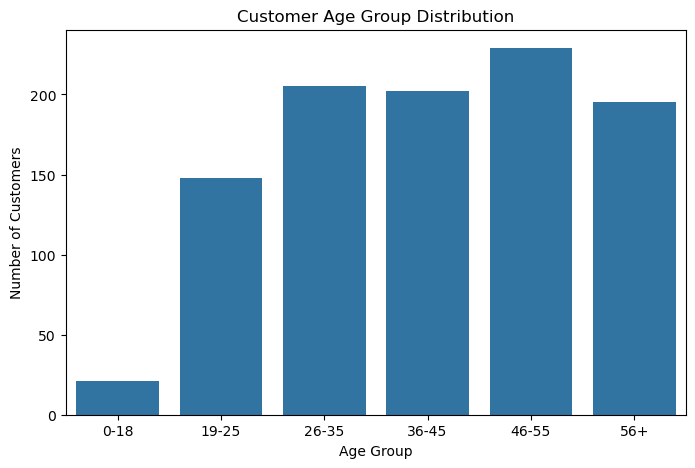

In [19]:
# Plot Age Group Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Age Group",
    order=age_labels
)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

## Observation

The chart illustrates the distribution of customers across different age groups. This analysis helps identify which age segment contributes the largest customer base and can assist businesses in designing targeted marketing strategies.

# Gender Distribution Analysis

Understanding the gender distribution of customers helps businesses identify their primary customer base. This analysis supports targeted marketing campaigns and product planning.

In [20]:
# Count customers by gender

df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

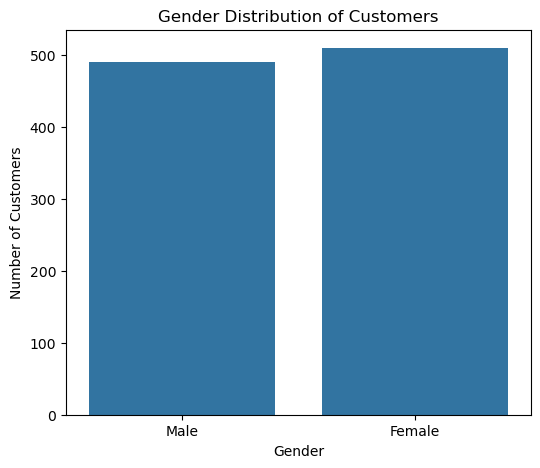

In [21]:
# Plot Gender Distribution

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## Observation

The chart shows the distribution of customers based on gender. Comparing the number of male and female customers helps understand the customer composition and can support targeted business and marketing strategies.

# Product Category Analysis

The dataset does not contain individual product names. Therefore, product category analysis is performed to understand customer purchasing preferences and identify the most frequently purchased product categories.

In [22]:
# Count transactions by product category

category_count = df["Product Category"].value_counts()

category_count

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

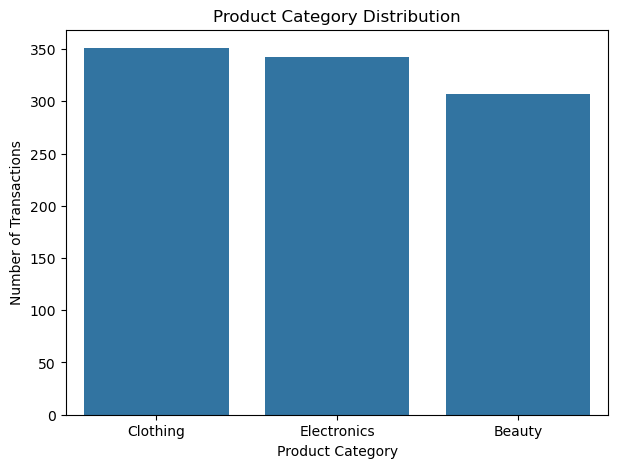

In [23]:
# Plot Product Category Distribution

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Product Category",
    order=category_count.index
)

plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")

plt.show()

## Observation

The chart shows the number of transactions for each product category. This helps identify which categories are purchased more frequently and provides insights into customer preferences.

# Revenue by Product Category

This analysis calculates the total revenue generated by each product category. It helps identify which product categories contribute the most to overall sales and supports business decisions related to inventory management and marketing.

In [24]:
# Calculate total revenue by product category

category_sales = df.groupby("Product Category")["Total Amount"].sum()

category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

## Observation

The table displays the total revenue generated by each product category. Categories with higher revenue contribute more significantly to the business's overall sales.

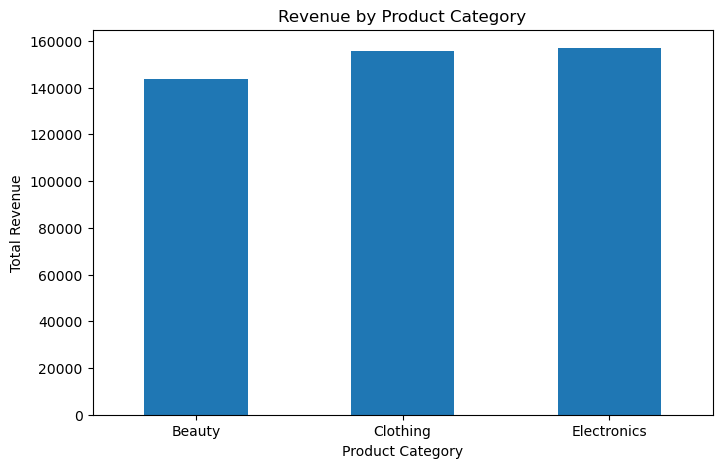

In [25]:
# Plot Revenue by Product Category

plt.figure(figsize=(8,5))

category_sales.plot(
    kind="bar"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)

plt.show()

## Observation

The bar chart compares the revenue generated by each product category. This visualization helps identify the highest-performing categories and supports data-driven business strategies such as inventory planning and promotional campaigns.

# Correlation Analysis

A correlation heatmap is used to measure the relationship between numerical variables in the dataset.

Correlation values range from **-1 to +1**:
- **+1** indicates a strong positive relationship.
- **-1** indicates a strong negative relationship.
- **0** indicates no relationship.

This analysis helps identify how different numerical features influence each other.

In [26]:
# Select numerical columns

numerical_df = df.select_dtypes(include=["int64", "float64"])

# Display correlation matrix

numerical_df.corr()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


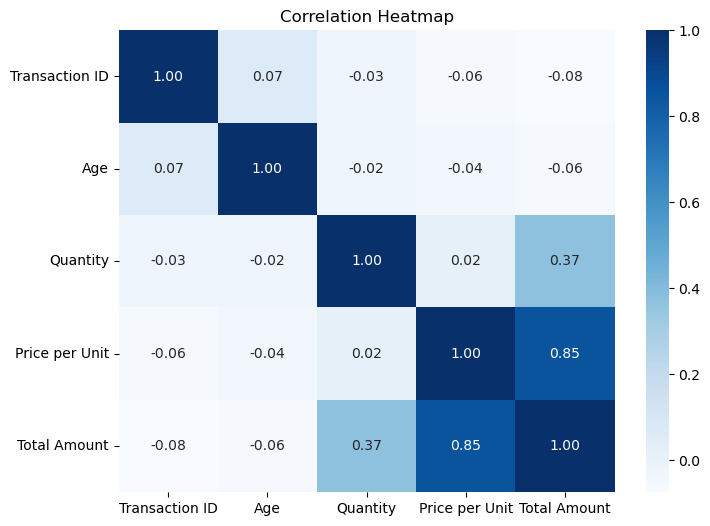

In [27]:
# Plot Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

The heatmap illustrates the correlation between numerical variables. Strong positive correlations indicate that two variables tend to increase together, while weak or negative correlations indicate little or inverse relationships. This analysis helps identify important factors that influence sales performance.

# Additional Visualization: Average Purchase Amount by Age Group

This visualization examines the average purchase amount across different age groups. It helps identify which customer segment spends more on average, providing valuable insights for targeted marketing and promotional strategies.

In [28]:
# Calculate average purchase amount by age group

avg_purchase = df.groupby("Age Group", observed=False)["Total Amount"].mean()

avg_purchase

Age Group
0-18     534.047619
19-25    495.506757
26-35    480.390244
36-45    454.801980
46-55    439.694323
56+      412.358974
Name: Total Amount, dtype: float64

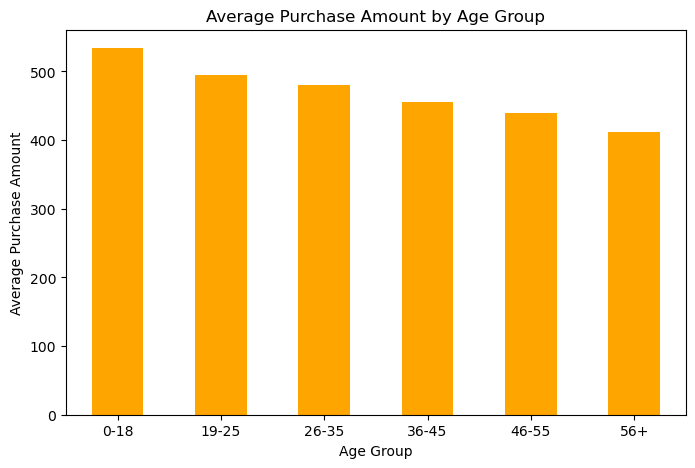

In [29]:
# Plot Average Purchase Amount by Age Group

plt.figure(figsize=(8,5))

avg_purchase.plot(
    kind="bar",
    color="orange"
)

plt.title("Average Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase Amount")

plt.xticks(rotation=0)

plt.show()

## Observation

The chart shows the average purchase amount for each age group. This analysis helps identify customer segments with higher spending behavior. Businesses can use these insights to design age-specific marketing campaigns, personalized offers, and loyalty programs.

# Business Recommendations

Based on the exploratory data analysis, the following business recommendations are suggested:

### 1. Focus on High-Revenue Product Categories
Product categories generating the highest revenue should be prioritized by maintaining sufficient inventory and promoting them through targeted marketing campaigns.

### 2. Target High-Spending Age Groups
The age groups with the highest average purchase amount should receive personalized offers, loyalty programs, and exclusive discounts to increase customer retention.

### 3. Improve Sales During Low-Performing Months
Sales trends indicate that some months generate lower revenue. Promotional campaigns, seasonal discounts, and festive offers can be introduced during these periods to boost sales.

### 4. Develop Gender-Specific Marketing Strategies
Customer purchasing behavior can be better addressed by designing marketing campaigns based on gender preferences where appropriate.

### 5. Monitor Sales Performance Regularly
Monthly and quarterly sales analysis should be performed regularly to identify changing customer trends and support better business decision-making.

# Conclusion

This project successfully performed Exploratory Data Analysis (EDA) on the Retail Sales Dataset using Python, Pandas, Matplotlib, and Seaborn.

The analysis included data inspection, descriptive statistics, monthly and quarterly sales trends, customer demographic analysis, product category analysis, correlation analysis, and additional business insights.

The findings provide valuable information about customer purchasing behavior and sales performance, enabling businesses to make informed decisions regarding inventory management, marketing strategies, and customer engagement.